In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

REFORM_COLOR = '#12239E'
ACCENT_COLOR = '#E8102A'

print("Imports OK")

Imports OK


In [2]:
df = pd.read_csv('../../data/processed/model_data.csv')

FEATURES = ['leave_vote_share', 'degree_pct', 'median_age', 'median_weekly_wage',
            'claimant_rate', 'foreign_born_pct', 'population_density',
            'ethnic_minority_pct', 'deprivation_score']

X = df[FEATURES]
y = df['reform_vote_share']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]} constituencies")
print(f"Test set     : {X_test.shape[0]} constituencies")

Training set : 504 constituencies
Test set     : 126 constituencies


In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr  = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
cv_lr  = cross_val_score(lr, X, y, cv=5, scoring='r2').mean()

print("Linear Regression")
print(f"  R²   (test) : {r2_lr:.4f}")
print(f"  MAE  (test) : {mae_lr:.4f}")
print(f"  RMSE (test) : {rmse_lr:.4f}")
print(f"  R²   (CV-5) : {cv_lr:.4f}")

Linear Regression
  R²   (test) : 0.7553
  MAE  (test) : 2.1818
  RMSE (test) : 3.3606
  R²   (CV-5) : 0.6666


In [7]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
cv_rf   = cross_val_score(rf, X, y, cv=5, scoring='r2').mean()

print("Random Forest")
print(f"  R²   (test) : {r2_rf:.4f}")
print(f"  MAE  (test) : {mae_rf:.4f}")
print(f"  RMSE (test) : {rmse_rf:.4f}")
print(f"  R²   (CV-5) : {cv_rf:.4f}")

Random Forest
  R²   (test) : 0.7092
  MAE  (test) : 2.3296
  RMSE (test) : 3.6638
  R²   (CV-5) : 0.6275


In [5]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

r2_gb   = r2_score(y_test, y_pred_gb)
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
cv_gb   = cross_val_score(gb, X, y, cv=5, scoring='r2').mean()

print("Gradient Boosting")
print(f"  R²   (test) : {r2_gb:.4f}")
print(f"  MAE  (test) : {mae_gb:.4f}")
print(f"  RMSE (test) : {rmse_gb:.4f}")
print(f"  R²   (CV-5) : {cv_gb:.4f}")

Gradient Boosting
  R²   (test) : 0.7471
  MAE  (test) : 2.3571
  RMSE (test) : 3.4168
  R²   (CV-5) : 0.5695


In [6]:
xgb_model = xgb.XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

r2_xgb   = r2_score(y_test, y_pred_xgb)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
cv_xgb   = cross_val_score(xgb_model, X, y, cv=5, scoring='r2').mean()

print("XGBoost")
print(f"  R²   (test) : {r2_xgb:.4f}")
print(f"  MAE  (test) : {mae_xgb:.4f}")
print(f"  RMSE (test) : {rmse_xgb:.4f}")
print(f"  R²   (CV-5) : {cv_xgb:.4f}")

XGBoost
  R²   (test) : 0.6923
  MAE  (test) : 2.3921
  RMSE (test) : 3.7683
  R²   (CV-5) : 0.5477


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

r2_brf   = r2_score(y_test, y_pred_best_rf)
mae_brf  = mean_absolute_error(y_test, y_pred_best_rf)
rmse_brf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
cv_brf   = cross_val_score(best_rf, X, y, cv=5, scoring='r2').mean()

print(f"Best params : {grid_rf.best_params_}")
print(f"R²   (test) : {r2_brf:.4f}")
print(f"MAE  (test) : {mae_brf:.4f}")
print(f"RMSE (test) : {rmse_brf:.4f}")
print(f"R²   (CV-5) : {cv_brf:.4f}")

Best params : {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}
R²   (test) : 0.7461
MAE  (test) : 2.1854
RMSE (test) : 3.4232
R²   (CV-5) : 0.6478


In [9]:
param_grid_gb = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'min_samples_leaf': [3, 5],
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb, cv=5, scoring='r2', n_jobs=-1
)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
y_pred_best_gb = best_gb.predict(X_test)

r2_bgb   = r2_score(y_test, y_pred_best_gb)
mae_bgb  = mean_absolute_error(y_test, y_pred_best_gb)
rmse_bgb = np.sqrt(mean_squared_error(y_test, y_pred_best_gb))
cv_bgb   = cross_val_score(best_gb, X, y, cv=5, scoring='r2').mean()

print(f"Best params : {grid_gb.best_params_}")
print(f"R²   (test) : {r2_bgb:.4f}")
print(f"MAE  (test) : {mae_bgb:.4f}")
print(f"RMSE (test) : {rmse_bgb:.4f}")
print(f"R²   (CV-5) : {cv_bgb:.4f}")

Best params : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 200}
R²   (test) : 0.7614
MAE  (test) : 2.2458
RMSE (test) : 3.3181
R²   (CV-5) : 0.6308


In [10]:
param_grid_xgb = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [3, 5],
}

grid_xgb = GridSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    param_grid_xgb, cv=5, scoring='r2', n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

r2_bxgb   = r2_score(y_test, y_pred_best_xgb)
mae_bxgb  = mean_absolute_error(y_test, y_pred_best_xgb)
rmse_bxgb = np.sqrt(mean_squared_error(y_test, y_pred_best_xgb))
cv_bxgb   = cross_val_score(best_xgb, X, y, cv=5, scoring='r2').mean()

print(f"Best params : {grid_xgb.best_params_}")
print(f"R²   (test) : {r2_bxgb:.4f}")
print(f"MAE  (test) : {mae_bxgb:.4f}")
print(f"RMSE (test) : {rmse_bxgb:.4f}")
print(f"R²   (CV-5) : {cv_bxgb:.4f}")

Best params : {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200}
R²   (test) : 0.7685
MAE  (test) : 2.1974
RMSE (test) : 3.2690
R²   (CV-5) : 0.6218


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest (tuned)',
        'Gradient Boosting (tuned)',
        'XGBoost (tuned)'
    ],
    'R² Test': [r2_lr, r2_brf, r2_bgb, r2_bxgb],
    'MAE Test': [mae_lr, mae_brf, mae_bgb, mae_bxgb],
    'RMSE Test': [rmse_lr, rmse_brf, rmse_bgb, rmse_bxgb],
    'R² CV-5': [cv_lr, cv_brf, cv_bgb, cv_bxgb],
    'Gap (Test-CV)': [
        r2_lr - cv_lr,
        r2_brf - cv_brf,
        r2_bgb - cv_bgb,
        r2_bxgb - cv_bxgb,
    ]
}).round(4)

display(results)

,Model,R² Test,MAE Test,RMSE Test,R² CV-5,Gap (Test-CV)
0,Linear Regression,0.7553,2.1818,3.3606,0.6666,0.0887
1,Random Forest (tuned),0.7461,2.1854,3.4232,0.6478,0.0983
2,Gradient Boosting (tuned),0.7614,2.2458,3.3181,0.6308,0.1307
3,XGBoost (tuned),0.7685,2.1974,3.2690,0.6218,0.1466


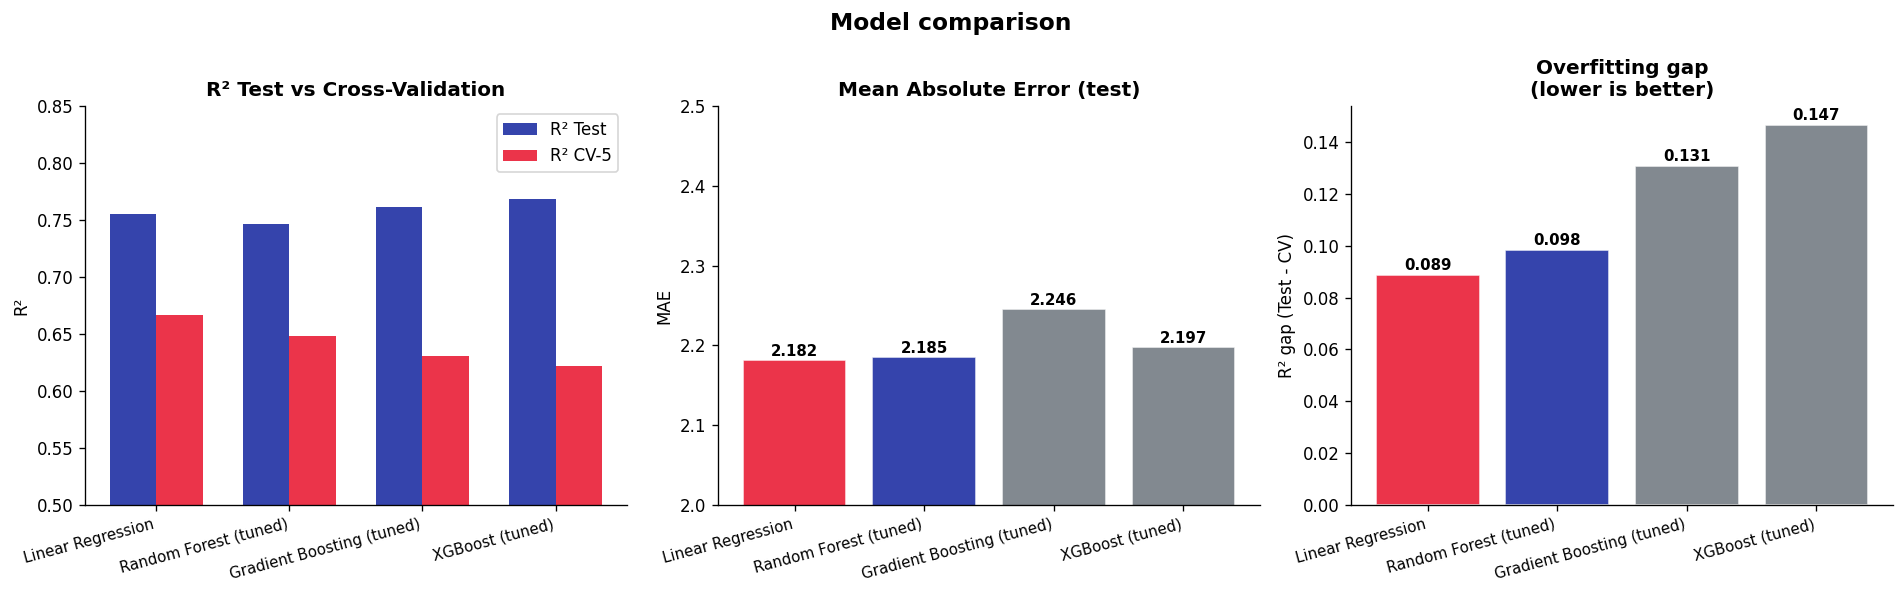

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models     = results['Model']
colors_bar = [ACCENT_COLOR, REFORM_COLOR, '#6c757d', '#6c757d']

# R² Test vs CV
ax = axes[0]
x = np.arange(len(models))
w = 0.35
ax.bar(x - w/2, results['R² Test'], w, label='R² Test', color=REFORM_COLOR, alpha=0.85)
ax.bar(x + w/2, results['R² CV-5'], w, label='R² CV-5', color=ACCENT_COLOR, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
ax.set_ylabel("R²")
ax.set_title("R² Test vs Cross-Validation", fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 0.85)

# MAE
ax = axes[1]
bars = ax.bar(models, results['MAE Test'], color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_ylabel("MAE")
ax.set_title("Mean Absolute Error (test)", fontweight='bold')
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
ax.set_ylim(2.0, 2.5)
for bar, val in zip(bars, results['MAE Test']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Gap Test - CV
ax = axes[2]
bars = ax.bar(models, results['Gap (Test-CV)'], color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_ylabel("R² gap (Test - CV)")
ax.set_title("Overfitting gap\n(lower is better)", fontweight='bold')
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
for bar, val in zip(bars, results['Gap (Test-CV)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle("Model comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/models_01_comparison.png', bbox_inches='tight')
plt.show()

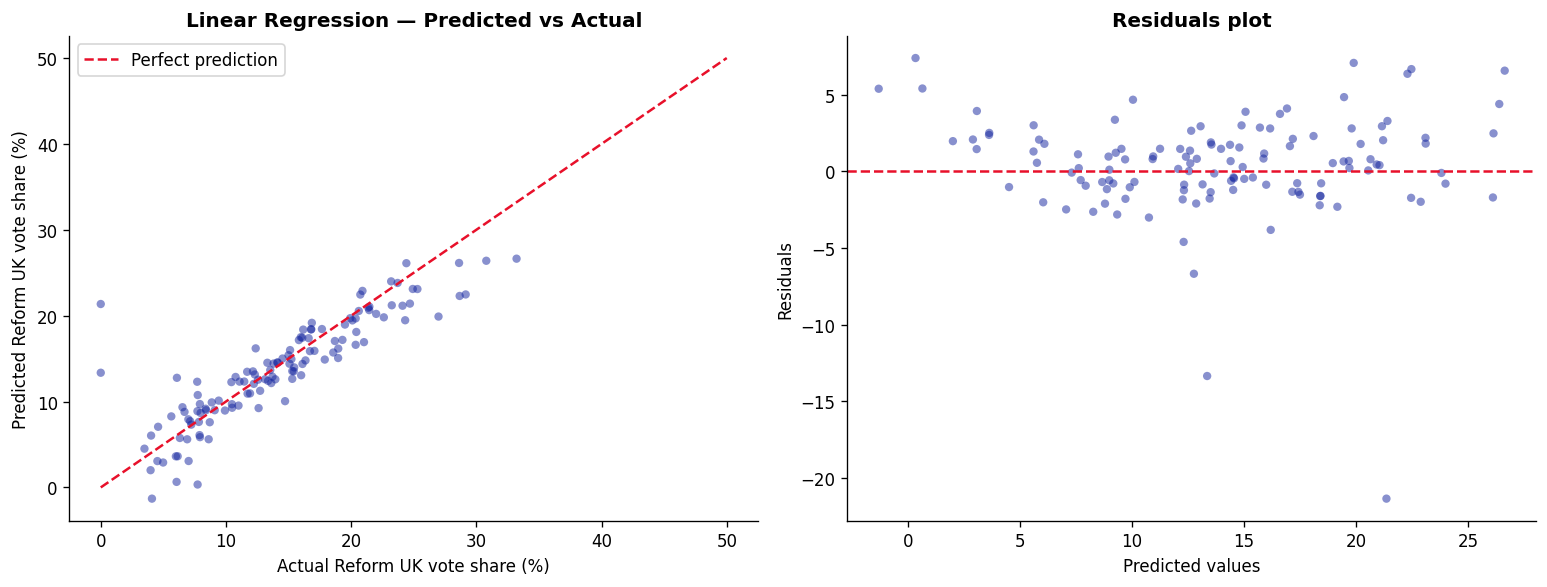

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
ax = axes[0]
ax.scatter(y_test, y_pred_lr, alpha=0.5, s=25, color=REFORM_COLOR, edgecolors='none')
lims = [0, 50]
ax.plot(lims, lims, color=ACCENT_COLOR, lw=1.5, linestyle='--', label='Perfect prediction')
ax.set_xlabel("Actual Reform UK vote share (%)")
ax.set_ylabel("Predicted Reform UK vote share (%)")
ax.set_title("Linear Regression — Predicted vs Actual", fontweight='bold')
ax.legend()

# Residuals
ax = axes[1]
residuals = y_test - y_pred_lr
ax.scatter(y_pred_lr, residuals, alpha=0.5, s=25, color=REFORM_COLOR, edgecolors='none')
ax.axhline(0, color=ACCENT_COLOR, lw=1.5, linestyle='--')
ax.set_xlabel("Predicted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals plot", fontweight='bold')

plt.tight_layout()
plt.savefig('../../outputs/models_02_residuals.png', bbox_inches='tight')
plt.show()

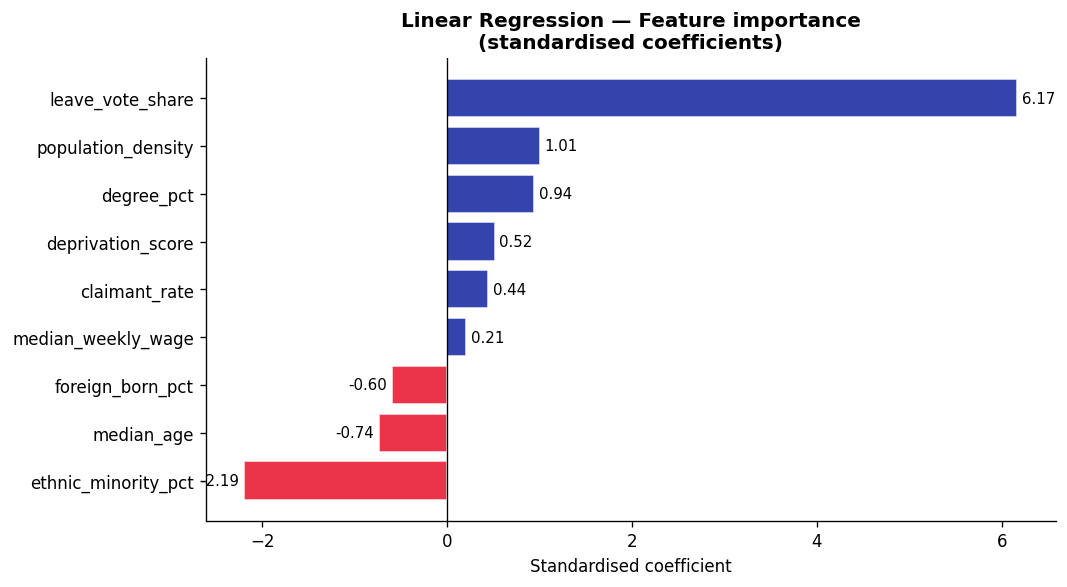

In [14]:
# Standardise pour rendre les coefficients comparables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr_scaled.coef_
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(9, 5))
colors_coef = [REFORM_COLOR if c > 0 else ACCENT_COLOR for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'],
               color=colors_coef, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel("Standardised coefficient")
ax.set_title("Linear Regression — Feature importance\n(standardised coefficients)", fontweight='bold')
for bar, val in zip(bars, coef_df['Coefficient']):
    ax.text(val + (0.05 if val >= 0 else -0.05),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9)

plt.tight_layout()
plt.savefig('../../outputs/models_03_feature_importance.png', bbox_inches='tight')
plt.show()

In [16]:
# Residual analysis for Linear Regression
# residual = actual - predicted
residuals = y_test - y_pred_lr

errors_df = pd.DataFrame({
    "constituency": df.loc[y_test.index, "constituency"].values,
    "actual": y_test.values,
    "predicted": y_pred_lr,
    "residual": residuals.values,
    "absolute_residual": np.abs(residuals.values)
})

# Cases where the model predicted too high:
# residual < 0 means actual < predicted
underpredicted = errors_df.sort_values("residual").head(5)

print("Model overestimation: actual vote share is lower than predicted")
display(underpredicted.round(2))


# Cases where the model predicted too low:
# residual > 0 means actual > predicted
overpredicted = errors_df.sort_values("residual", ascending=False).head(5)

print("\nModel underestimation: actual vote share is higher than predicted")
display(overpredicted.round(2))


# Largest prediction errors overall
largest_errors = errors_df.sort_values("absolute_residual", ascending=False).head(10)

print("\nLargest prediction errors overall")
display(largest_errors.round(2))

Model overestimation: actual vote share is lower than predicted


,constituency,actual,predicted,residual,absolute_residual
76,Sheffield South East,0.00,21.36,-21.36,21.36
42,Bristol East,0.00,13.35,-13.35,13.35
50,Dundee Central,6.08,12.76,-6.68,6.68
85,West Ham and Beckton,7.70,12.31,-4.60,4.60
20,Chippenham,12.37,16.19,-3.82,3.82



Model underestimation: actual vote share is higher than predicted


,constituency,actual,predicted,residual,absolute_residual
87,Greenwich and Woolwich,7.74,0.34,7.40,7.40
4,Sunderland Central,26.98,19.90,7.08,7.08
51,Houghton and Sunderland South,29.15,22.47,6.68,6.68
71,Barnsley South,33.21,26.64,6.58,6.58
52,Amber Valley,28.67,22.30,6.37,6.37



Largest prediction errors overall


,constituency,actual,predicted,residual,absolute_residual
76,Sheffield South East,0.00,21.36,-21.36,21.36
42,Bristol East,0.00,13.35,-13.35,13.35
87,Greenwich and Woolwich,7.74,0.34,7.40,7.40
4,Sunderland Central,26.98,19.90,7.08,7.08
50,Dundee Central,6.08,12.76,-6.68,6.68
51,Houghton and Sunderland South,29.15,22.47,6.68,6.68
71,Barnsley South,33.21,26.64,6.58,6.58
52,Amber Valley,28.67,22.30,6.37,6.37
32,Hampstead and Highgate,6.06,0.64,5.41,5.41
114,Hornsey and Friern Barnet,4.09,-1.31,5.40,5.40


## Key Findings

The Brexit Leave vote share is by far the dominant predictor (standardised 
coefficient = 6.17), confirming the strong continuity between the 2016 referendum 
and the 2024 Reform vote.

Ethnic minority share shows the strongest negative effect (-2.19): highly diverse 
constituencies vote significantly less for Reform, independently of other variables.

The two largest prediction errors (Sheff